In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pickle

from scipy.optimize import curve_fit

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


##  Signal time constants

In [30]:
# colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']
# Wong (2011) colorblind-safe palette – 8 distinct colors
# Works for deuteranopia, protanopia, and tritanopia

# Grayscale palette – 10 shades from near-black to light gray
# Paired with distinct markers and line styles for full grayscale legibility
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown        
    '#006CD1',  # Cerulean     
]

colors = CB_COLORS

# Distinct markers and line styles for extra redundancy (grayscale-safe)
CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


In [31]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


In [32]:
base    = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data"

##  Functions

In [33]:
def _rise_decay_normalised(t, t0, rise, decay):
    """Unit-area (1-exp)×exp pulse anchored at t0, zero for t < t0."""
    s = np.zeros_like(t, dtype=float)
    mask = t >= t0
    s[mask] = (1.0 - np.exp(-(t[mask]-t0) / rise)) * np.exp(-(t[mask]-t0) / decay)
    area = np.trapz(s, x=t)
    return s / (area if area != 0 else 1.0)



In [34]:

def ResponseSiPM(q_in_pes, t, t0, rise_time, decay_time, baseline=0.0):
    """
    SiPM single-PE pulse: area-normalised (1-exp)×exp, scaled by q_in_pes.

    Parameters
    ----------
    q_in_pes   : float   charge [PE] — sets the integral
    t          : array   time axis [s]
    t0         : float   pulse onset [s]
    rise_time  : float   rise  constant [s]   (SiPM typical ~5 ns)
    decay_time : float   decay constant [s]   (SiPM typical ~40 ns)
    baseline   : float   DC offset [mV]
    """
    return q_in_pes * _rise_decay_normalised(t, t0, rise_time, decay_time) + baseline



In [35]:
def _check_bounds(popt, bounds_ch, label, names):
    """
    Check if any fitted parameter landed within 1% of its hard bounds.
    Prints a warning for each parameter that is close to a bound.

    Parameters
    ----------
    popt      : array   fitted parameter values
    bounds_ch : tuple   (lower, upper) lists
    label     : str     identifier for the warning message (e.g. channel name)
    names     : list    parameter names, same length as popt
    """
    tol = 0.01
    for i, (p, lo, hi) in enumerate(zip(popt, bounds_ch[0], bounds_ch[1])):
        span = (hi - lo) if not np.isinf(hi) else None
        if span is not None:
            if np.abs(p - lo) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: '
                      f'value={p:.4e}  lower={lo:.4e}')
            elif np.abs(p - hi) < tol * span:
                print(f'  ⚠ [{label}] {names[i]:12s} hit upper bound: '
                      f'value={p:.4e}  upper={hi:.4e}')
        else:
            # hi is inf — only check lower bound with relative tolerance
            if p > 0 and np.abs(p - lo) / p < tol:
                print(f'  ⚠ [{label}] {names[i]:12s} hit lower bound: '
                      f'value={p:.4e}  lower={lo:.4e}')

In [36]:
def _I(p, q, u):
    """
    I(p, q, u) = integral_0^u  exp(-p*s) * exp(-q*(u-s)) ds

    p = rate of the 'left'  factor in the integrand  (units: 1/s)
    q = rate of the 'right' factor in the integrand  (units: 1/s)
    u = shifted time from pulse onset  (units: s),  u >= 0

    Result:
        (exp(-p*u) - exp(-q*u)) / (q - p)   if p != q
        u * exp(-p*u)                         if p == q  (L'Hopital)
    """
    if np.abs(p - q) < 1e-30:
        return u * np.exp(-p * u)
    return (np.exp(-p * u) - np.exp(-q * u)) / (q - p)


In [37]:
def _conv_two_rise_decay(u, rise1, decay1, rise2, decay2):
    """
    Analytical convolution of two (1-exp)*exp pulses starting at u=0.

    Expanding f1 = exp(-a*s) - exp(-b*s)
    with  a = 1/decay1
          b = 1/rise1 + 1/decay1

    and f2 = exp(-c*(u-s)) - exp(-d*(u-s))
    with  c = 1/decay2
          d = 1/rise2 + 1/decay2

    gives 4 I() terms:
        h(u) = I(a,c,u) - I(a,d,u) - I(b,c,u) + I(b,d,u)
    """
    a = 1.0 / decay1
    b = 1.0 / rise1 + 1.0 / decay1
    c = 1.0 / decay2
    d = 1.0 / rise2 + 1.0 / decay2

    return _I(a,c,u) - _I(a,d,u) - _I(b,c,u) + _I(b,d,u)



In [38]:
def CIGARResponse_analytical(t, t0,
                             A_singlet, rise_singlet, tau_singlet,
                             A_triplet, rise_triplet, tau_triplet,
                             baseline=0.0):
    """CIGAR = singlet + triplet + recombination + baseline.
    SiPM shape fixed: rise=1 ns, decay=64 ns.
    Singlet and triplet rise/decay are FREE parameters.
    All convolution branches area-normalised before amplitude scaling.
    """
    sipm_rise  = 1e-9
    sipm_decay = 64e-9
    u    = t - t0
    mask = u > 0

    h_singlet       = np.zeros_like(t, dtype=float)
    h_singlet[mask] = _conv_two_rise_decay(u[mask], rise_singlet, tau_singlet, sipm_rise, sipm_decay)
    area = np.trapz(h_singlet, x=t)
    if area > 0: h_singlet *= A_singlet / area

    h_triplet       = np.zeros_like(t, dtype=float)
    h_triplet[mask] = _conv_two_rise_decay(u[mask], rise_triplet, tau_triplet, sipm_rise, sipm_decay)
    area = np.trapz(h_triplet, x=t)
    if area > 0: h_triplet *= A_triplet / area
    
    return baseline + h_singlet + h_triplet


In [39]:
def _enforce_rise_lt_tau(popt, bounds_ch):
    """
    After each refinement step, tighten bounds so that:
        rise_fast < tau_fast  (indices 2, 3)
        rise_slow < tau_slow  (indices 5, 6)
    This prevents the degenerate solution where decay < rise,
    which produces a physically meaningless collapsing pulse.
    """
    lower = np.minimum(popt * 0.6, popt * 1.4)
    upper = np.maximum(popt * 0.6, popt * 1.4)

    # enforce rise < tau by capping rise upper below current tau and vice versa
    upper[2] = min(upper[2], popt[3] * 0.99)   # rise_fast < tau_fast
    lower[3] = max(lower[3], popt[2] * 1.01)   # tau_fast  > rise_fast
    upper[5] = min(upper[5], popt[6] * 0.99)   # rise_slow < tau_slow
    lower[6] = max(lower[6], popt[5] * 1.01)   # tau_slow  > rise_slow

    # clip against original hard bounds
    lower = np.maximum(lower, bounds_ch[0])
    upper = np.minimum(upper, bounds_ch[1])

    # popt is always inside [popt*0.8, popt*1.2] by construction,
    # but clipping against hard bounds can exclude it — restore in that case
    for i in range(len(popt)):
        if not (lower[i] <= popt[i] <= upper[i]):
            lower[i] = bounds_ch[0][i]
            upper[i] = bounds_ch[1][i]

    return lower.tolist(), upper.tolist()

In [40]:
def fit_cigar_waveforms(runs_dict, base,
                        pretrigger_sample=125,
                        channels_to_show=None, invert=True,
                        p0_cigar=None, bounds_cigar=None,
                        colors=None, font_size=14, logscale=False):
    """
    Load CIGAR mean waveforms (.npz), overplot all runs, fit
    CIGARResponse_analytical to the first run per channel.

    Uses the fully analytical convolution — no np.convolve, no edge effects,
    much faster to evaluate inside the fitter.

    Channel indexing
    ----------------
    CIGAR signal     : physical names   → e.g. 'CH4','CH6','CH8','CH10'
    ch_idx (0,1,2,3) bridges them: sipm_params[f'CH{ch_idx+1}'] maps
    the i-th CIGAR channel to the i-th SPhe calibration.

    Parameters
    ----------
    runs_dict         : dict {label: run_name_or_int}
                        all runs overplotted; first used for fitting
    base              : str   base directory
    pretrigger_sample : int   sample index where pulse starts (default 125 = 1 µs)
    channels_to_show  : list or None   channel indices; None → all (max 4)
    invert            : bool
    p0_cigar          : dict {ch: [t0_ar, A_fast, rise_fast, tau_fast,
                                           A_slow, rise_slow, tau_slow,
                                           delta_slow]} or None (auto)
                        baseline is NOT included — always estimated from
                        the waveform tail internally
    bounds_cigar      : dict {ch: (lower_list, upper_list)} or None (auto)
                        baseline bounds handled internally (0 to 5 mV)
    colors            : list of colours (one per run label)
    font_size         : int
    logscale          : bool  set y-axis to log scale

    Returns
    -------
    fig          : Figure
    axs          : 2×2 array of Axes
    cigar_params : dict {ch: {t0_ar, A_fast, rise_fast, tau_fast,
                                       A_slow, rise_slow, tau_slow,
                                       delta_slow, baseline, pcov}}
    """
    if colors is None:
        colors = ['steelblue', 'lightcoral', 'darkseagreen', 'darkorchid', 'darkorange', 'goldenrod', 'tomato', 'plum']

    # 1. LOAD ---------------------------------------------------------------- #
    runs_fmt = {lbl: (f'Run{r}' if isinstance(r, int) else r)
                for lbl, r in runs_dict.items()}
    all_data = {lbl: np.load(f'{base}/mean_waveforms/mean_waveforms_{rn}.npz',
                             allow_pickle=True)
                for lbl, rn in runs_fmt.items()}

    first_lbl = list(runs_fmt.keys())[0]
    channels  = all_data[first_lbl]['channels']

    if channels_to_show is None:
        channels_to_show = list(range(len(channels)))

    # 2. FIGURE -------------------------------------------------------------- #
    run_labels = ', '.join(f'{lbl} bar' for lbl in runs_fmt)
    fig, axs   = plt.subplots(2, 2, figsize=(20, 14), dpi=150)
    fig.suptitle(f'CIGAR mean waveforms — analytical SiPM ⊛ GArResponse\n'
                 f'{run_labels}', fontsize=font_size + 2)

    cigar_params = {}

    for plot_i, ch_idx in enumerate(channels_to_show[:4]):
        ax       = axs.flat[plot_i]
        ch       = channels[ch_idx]
        sphe_key = f'CH{ch_idx + 1}'

        # 3. LOAD & OVERPLOT ALL RUNS ---------------------------------------- #
        wf_target, time_fit = None, None
        for ii, (lbl, rn) in enumerate(runs_fmt.items()):
            wf = all_data[lbl][f'ch_{ch}'].copy()
            t  = all_data[lbl]['time']
            if invert:
                wf = -wf
            if ii == 0:
                wf_target, time_fit = wf, t
            ax.plot(t * 1e6, wf, '-o', lw=2,
                    color=colors[ch_idx], alpha=0.55,
                    label=f'{lbl} bar data')

        # 4. PRETRIGGER ------------------------------------------------------ #
        # t0 known from hardware: sample 125 = 1 µs
        t0_fixed  = time_fit[pretrigger_sample]
        dt_samp   = time_fit[1] - time_fit[0]
        t0_window = 5 * dt_samp

        # 5. FIT REGION — only t >= t0_fixed --------------------------------- #
        fit_mask = time_fit >= t0_fixed
        t_fit    = time_fit[fit_mask]
        wf_fit   = wf_target[fit_mask]

        # 6. INITIAL GUESS --------------------------------------------------- #
        # baseline: estimated from tail — always positive (abs) since log scale
        # t0_ar:    always from pretrigger — not a user input
        baseline_est = np.mean(wf[:pretrigger_sample//2])
        baseline_est_err = np.std(wf[:pretrigger_sample//2])/np.sqrt(pretrigger_sample//2)
        # print(f'baseline  = {baseline_est}')

        if p0_cigar is not None and ch in p0_cigar:
            # user supplies [t0_ar, A_fast, rise_fast, tau_fast,
            #                A_slow, rise_slow, tau_slow, delta_slow]
            # baseline appended automatically from tail estimate
            p0_ch = list(p0_cigar[ch]) 
        else:
            A_tot        = max(np.trapz(wf_fit, x=t_fit),
                               wf_fit.max() * (t_fit[-1] - t_fit[0]) * 0.1)

            p0_ch = [
                t0_fixed,                        # t0_ar
                A_tot * 9,    2e-9,   20e-9,     # fast: A, rise, tau
                A_tot * 3,  300e-9,  4.5e-6,     # slow: A, rise, tau
            ]

        # print(f'p0_ch = {p0_ch}')

        # 7. BOUNDS ---------------------------------------------------------- #
        # physical constraints enforced here:
        #   rise_fast < tau_fast : upper(rise_fast) < lower(tau_fast)
        #   rise_slow < tau_slow : upper(rise_slow) < lower(tau_slow)
        #   baseline  >= 0       : unphysical to have negative DC offset
        if bounds_cigar is not None and ch in bounds_cigar:
            user_lower, user_upper = bounds_cigar[ch]
            bounds_ch = (
                list(user_lower),
                list(user_upper),
            )

        # else:
        #     lower = [t0_fixed - t0_window,        # t0_ar
        #              0,    1e-11,   10e-9,         # fast: A, rise_fast, tau_fast
        #              0,    20e-8,   800e-9,        # slow: A, rise_slow, tau_slow >= 800 ns > rise_slow_max (700 ns)
        #              1e-8, -baseline_est * 1.001]  # delta_slow >= 200 ns, baseline
        #     upper = [t0_fixed + t0_window,
        #              np.inf, 50e-9,  100e-9,       # rise_fast upper (50 ns) < tau_fast upper (100 ns)
        #              np.inf, 700e-9, 10e-6,        # rise_slow upper (700 ns) < tau_slow lower (800 ns)
        #              5e-6,   baseline_est * 1.001] # delta_slow <= 5 µs, baseline
        #     bounds_ch = (lower, upper)
        else:
            lower = [t0_fixed - t0_window,        # t0_ar
                     0,    1e-11,   5e-9,         # fast: A, rise_fast, tau_fast
                     0,    1e-8,    1e-6,         # slow: A, rise_slow, tau_slow >= 800 ns > rise_slow_max (700 ns)
                     ]  
            upper = [t0_fixed + t0_window,
                     np.inf, 100e-9,  200e-9,      # rise_fast upper (50 ns) < tau_fast upper (100 ns)
                     np.inf, 900e-9, 15e-6,        # rise_slow upper (700 ns) < tau_slow lower (800 ns)
                     ]  
            bounds_ch = (lower, upper)
        
            # rise_fast upper (50 ns) <= tau_fast lower (50 ns) enforces rise < tau
            # rise_slow upper (500 ns) <= tau_slow lower (1e-7 = 100 ns)... 
            # wait — tau_slow lower must be > rise_slow upper:
            # rise_slow upper = 500 ns → tau_slow lower must be > 500 ns
        # print(f'lower = {lower}')
        # print(f'upper = {upper}')

        # clip t0_ar and delta_slow strictly inside bounds
        # (least_squares requires x0 strictly inside [lb, ub])
        p0_ch[0] = np.clip(p0_ch[0],
                           bounds_ch[0][0] + 1e-12,
                           bounds_ch[1][0] - 1e-12)
        

        # 8. FIT ------------------------------------------------------------- #

        def fit_fn(t, t0_ar, Af, rf, df, As, rs, ds):
            return CIGARResponse_analytical(t, t0_ar,
                                            Af, rf, df,
                                            As, rs, ds,
                                            baseline=baseline_est, 
                                            )

        try:
            popt, pcov = curve_fit(fit_fn, t_fit, wf_fit,
                                   p0=p0_ch, bounds=bounds_ch, maxfev=10_000)

            # refinement: tighten to ±40% around current solution
            # each iteration also enforces rise < tau
            for ii in range(10):
                # print(ii)
                lower, upper = _enforce_rise_lt_tau(popt, bounds_ch)
                popt, pcov   = curve_fit(fit_fn, t_fit, wf_fit,
                                         p0=popt, bounds=(lower, upper),
                                         maxfev=1_000)

            _check_bounds(popt, bounds_ch, sphe_key,
                                    names=['t0_ar', 'A_fast', 'rise_fast', 'tau_fast',
                                            'A_slow', 'rise_slow', 'tau_slow',
                                            ])

            perr, fit_ok = np.sqrt(np.diag(pcov)), True

        except RuntimeError as e:
            print(f'[{sphe_key}] CIGAR fit failed: {e}')
            popt, pcov   = np.array(p0_ch), np.full((9, 9), np.nan)
            perr, fit_ok = np.full(9, np.nan), False

        t0_ar_, Af, rf, df, As, rs, ds = popt
        bl = baseline_est
        cigar_params[sphe_key] = dict(
            t0_ar      = t0_ar_,
            A_fast     = Af,  rise_fast  = rf,  tau_fast   = df,
            A_slow     = As,  rise_slow  = rs,  tau_slow   = ds,
            baseline   = baseline_est,
            pcov       = pcov,
        )

        # 9. PLOT ------------------------------------------------------------ #
        if fit_ok:
            ax.plot(t_fit * 1e6, fit_fn(t_fit, *popt),
                    color='black', lw=2, ls='-', label='Full fit', zorder=5)

            print(f'5: {len(t_fit) - len(wf_fit)}')

            # individual branches at actual fitted amplitudes
            u_fast = t_fit - t0_ar_
            h_fast = np.zeros_like(t_fit)
            mf     = u_fast > 0
            h_fast[mf] = _conv_two_rise_decay(u_fast[mf], 1e-9, 64e-9, rf, df)
            area = np.trapz(h_fast, x=t_fit)
            if area > 0: h_fast *= Af / area

            u_slow = t_fit - t0_ar_
            h_slow = np.zeros_like(t_fit)
            ms     = u_slow > 0
            h_slow[ms] = _conv_two_rise_decay(u_slow[ms], 1e-9, 64e-9, rs, ds)
            area = np.trapz(h_slow, x=t_fit)
            if area > 0: h_slow *= As / area

            ax.plot(t_fit * 1e6, h_fast + bl, '--', lw=3,
                            alpha=0.7, color='#009E73')
            ax.fill_between(t_fit * 1e6, bl, h_fast + bl,
                            alpha=0.2, color='#009E73')
            
            ax.plot(t_fit * 1e6, h_slow + bl, '--', lw=3,
                            alpha=0.7, color='#006CD1')
            ax.fill_between(t_fit * 1e6, bl, h_slow + bl,
                            alpha=0.2, color='#006CD1')

            ax.annotate(
                fr"fast  $\tau$ = {df*1e9:.1f} $\pm$ {perr[3]*1e9:.1f} ns" + "\n"
                fr"slow  $\tau$ = {ds*1e6:.2f} $\pm$ {perr[6]*1e6:.2f} $\mu$s" + "\n"
                fr"baseline = {baseline_est:.3f} $\pm$ {baseline_est_err:.3f} mV" + "\n"
                fr"slow/fast = {As/Af:.2f}",
                xy=(0.8, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=font_size * 0.70,
                bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.82),
            )


            ax2 = ax.twinx()

            ax2.plot(t_fit * 1e6, wf_fit - fit_fn(t_fit, *popt),
                     color='gray', lw=1, alpha=0.5)
            
            ax2.axhline(0, color='gray', lw=0.8, ls=':')
            ax2.set_ylabel('Residuals [mV]', fontsize=font_size * 0.7, color='gray')
            ax2.tick_params(axis='y', labelcolor='gray')


        # ax.axvline(t0_fixed * 1e6, color='k', ls=':', alpha=0.4, label=f't₀ = {t0_fixed*1e6:.2f} µs')
        ax.axhline(0, color='k', ls=':', alpha=0.3)
        ax.set_title(f'{sphe_key}', fontsize=font_size)
        ax.set_ylabel('Amplitude [mV]', fontsize=font_size * 0.85)
        ax.set_xlabel('Time [µs]', fontsize=font_size * 0.85)
        ax.legend(loc=(0.4, 0.78), fontsize=font_size * 0.60)

        ax.set_xlim(0, 16) # [us]

        if logscale:
            ax.set_yscale('log')
            ax.set_ylim(1e-1, wf_fit.max() * 2)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig, axs, cigar_params

##  SiPM time constants

In [41]:

# =========================================================================== #
#  SPhe — LOAD 4 .npz (one per channel), FIT SiPM RESPONSE, 2×2 PLOT          #
# =========================================================================== #

def fit_sphe_waveforms(run_base_sphe, base, all_channels,
                       invert=True, p0=None, bounds=None,
                       colors=None, font_size=14):
    """
    Load pre-saved SPhe mean-waveform .npz files (one per channel run),
    fit ResponseSiPM to each channel, return SiPM parameters.

    Each channel's .npz lives at:
        {base}/mean_waveforms/mean_waveforms_{run_base_sphe}{ch_num}.npz
    e.g. mean_waveforms_Run172SPheCH1.npz

    Parameters
    ----------
    run_base_sphe : str   e.g. 'Run172SPheCH'  (channel number appended)
    base          : str   base directory (same everywhere in your pipeline)
    all_channels  : list  e.g. ['CH1','CH2','CH3','CH4']
    invert        : bool  flip sign before fitting (your pulses are negative)
    p0            : dict  {ch: [A, t0, rise, tau, baseline]} or None (auto)
    bounds        : dict  {ch: (lower_list, upper_list)}     or None (auto)
    colors        : list  4 colours
    font_size     : int

    Returns
    -------
    fig         : Figure
    sipm_params : dict {ch: {'A','t0','rise','tau','baseline','pcov'}}
    """
    if colors is None:
        colors = ['steelblue', 'tomato', 'seagreen', 'darkorchid']

    # 1. LOAD ---------------------------------------------------------------- #
    channel_data = {}
    for ch_idx, ch in enumerate(all_channels):
        run_name = f'{run_base_sphe}{ch_idx + 1}'
        npz_path = f'{base}/mean_waveforms/mean_waveforms_{run_name}.npz'
        channel_data[ch] = np.load(npz_path, allow_pickle=True)
        print(f'Loaded {npz_path}')

    time = channel_data[all_channels[0]]['time']

    # 2. FIGURE -------------------------------------------------------------- #
    n_rows = len(all_channels)//2 + len(all_channels)%2
    fig, axs = plt.subplots(n_rows, 2, figsize=(18, 6*n_rows), dpi=150, sharex=False)
    fig.suptitle(f'SPhe mean waveforms — SiPM fit   [{run_base_sphe}*]',
                 fontsize=font_size + 2)

    sipm_params = {}

    for i, ch in enumerate(all_channels):
        ax  = axs.flat[i]
        npz = channel_data[ch]

        # 3. WAVEFORM -------------------------------------------------------- #
        wf = npz[f'ch_{ch}'].copy()
        if invert:
            wf = -wf
        # baseline correction 
        wf -= wf[:10].mean()

        # 4. INITIAL GUESS --------------------------------------------------- #
        if p0 is not None and ch in p0:
            p0_ch  = list(p0[ch])
            t0_est = p0_ch[1]
        else:
            pk     = np.argmax(wf)
            t0_est = time[pk - 3]
            A_est  = max(np.trapz(wf, x=time),
                         wf.max() * (time[-1] - time[0]) * 0.1)
            baseline_est = wf[-10:].mean()
            p0_ch  = [A_est,  # amplitude
                      t0_est, # t0
                      50e-9,  # rise
                      150e-9, # decay
                      baseline_est    # baseline
                      ]

        # 5. BOUNDS ---------------------------------------------------------- #
        if bounds is not None and ch in bounds:
            bounds_ch = bounds[ch]
        else:
            bounds_ch = (
                [0,       time[0],  15e-9,  1e-9,    min(baseline_est * 0.8, baseline_est * 1.2)],   # lower
                [np.inf, time[-1], 100e-9,  6e-6,    max(baseline_est * 0.8, baseline_est * 1.2)],   # upper
            )

        # clip t0 to be strictly inside bounds (least_squares requirement)
        p0_ch[1] = np.clip(p0_ch[1],
                           bounds_ch[0][1] + 1e-12,
                           bounds_ch[1][1] - 1e-12)
        
        # 6. FIT REGION — a few samples before the peak to end of waveform
        pk_idx   = np.argmax(wf)
        start    = max(0, pk_idx - 5) # 10 samples before the peak
        time_fit = time[start:]
        wf_fit   = wf[start:]

        # 7. FIT ------------------------------------------------------------- #
        def fit_fn(t, A, t0, rise, tau, bl):
            return ResponseSiPM(A, t, t0, rise, tau, bl)

        try:
            # broad fit
            popt, pcov = curve_fit(fit_fn, time_fit, wf_fit,
                                   p0=p0_ch, bounds=bounds_ch, maxfev=20_000)

            # refinement: tighten bounds to ±20% around current solution
            for _ in range(10):
                lower      = np.minimum(popt * 0.8, popt * 1.2)
                upper      = np.maximum(popt * 0.8, popt * 1.2)
                popt, pcov = curve_fit(fit_fn, time_fit, wf_fit,
                                       p0=popt, bounds=(lower, upper),
                                       maxfev=20_000)
                
            _check_bounds(popt, bounds_ch, ch,
                                    names=['t0', 'A', 'rise', 'tau', 'baseline'])

            perr, fit_ok = np.sqrt(np.diag(pcov)), True

        except RuntimeError as e:
            print(f'[{ch}] SPhe fit failed: {e}')
            popt, pcov   = np.array(p0_ch), np.full((5, 5), np.nan)
            perr, fit_ok = np.full(5, np.nan), False

        sipm_params[ch] = dict(A=popt[0], t0=popt[1], rise=popt[2],
                               tau=popt[3], baseline=popt[4], pcov=pcov)

        # 8. PLOT ------------------------------------------------------------ #
        # full waveform on original time axis
        ax.plot(time * 1e6, wf,
                color=colors[i], lw=2.5, alpha=0.8, label='Mean SPhe data')

        if fit_ok:
            # model and residuals only over the fit region (t >= t0_est)
            wf_model = fit_fn(time_fit, *popt)

            ax.plot(time_fit * 1e6, wf_model,
                    color='black', lw=2.2, ls='--',
                    label=(f'SiPM fit\n'
                           f'rise = {popt[2]*1e9:.1f} ± {perr[2]*1e9:.1f} ns'+ "\n"
                           f'τ    = {popt[3]*1e9:.1f} ± {perr[3]*1e9:.1f} ns'+ "\n"
                           f'baseline = {popt[4]:.1f} ± {perr[4]:.1f} mV'
                           )
                           )

            ax2 = ax.twinx()
            ax2.plot(time_fit * 1e6, wf_fit - wf_model,
                     color='gray', lw=1, alpha=0.5)
            ax2.axhline(0, color='gray', lw=0.8, ls=':')
            ax2.set_ylabel('Residuals [mV]', fontsize=font_size * 0.7, color='gray')
            ax2.tick_params(axis='y', labelcolor='gray')

        ax.axhline(0, color='k', ls=':', alpha=0.3)
        ax.set_title(f'{ch}', fontsize=font_size)
        ax.set_ylabel('Amplitude [mV]', fontsize=font_size * 0.85)
        ax.set_xlabel(r'Time [$\mu$s]', fontsize=font_size * 0.85)
        ax.legend(loc='upper right', fontsize=font_size * 0.65)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, axs, sipm_params

In [42]:
run_base_sphe     = 'Run174SPheCH'   # prefix; per-channel run dirs: Run172SPheCH1, Run172SPheCH2, ...

Loaded /home/marian/CIGAR_ANALYSIS/CIGAR/data/mean_waveforms/mean_waveforms_Run174SPheCH1.npz
Loaded /home/marian/CIGAR_ANALYSIS/CIGAR/data/mean_waveforms/mean_waveforms_Run174SPheCH2.npz
Loaded /home/marian/CIGAR_ANALYSIS/CIGAR/data/mean_waveforms/mean_waveforms_Run174SPheCH3.npz
Loaded /home/marian/CIGAR_ANALYSIS/CIGAR/data/mean_waveforms/mean_waveforms_Run174SPheCH4.npz


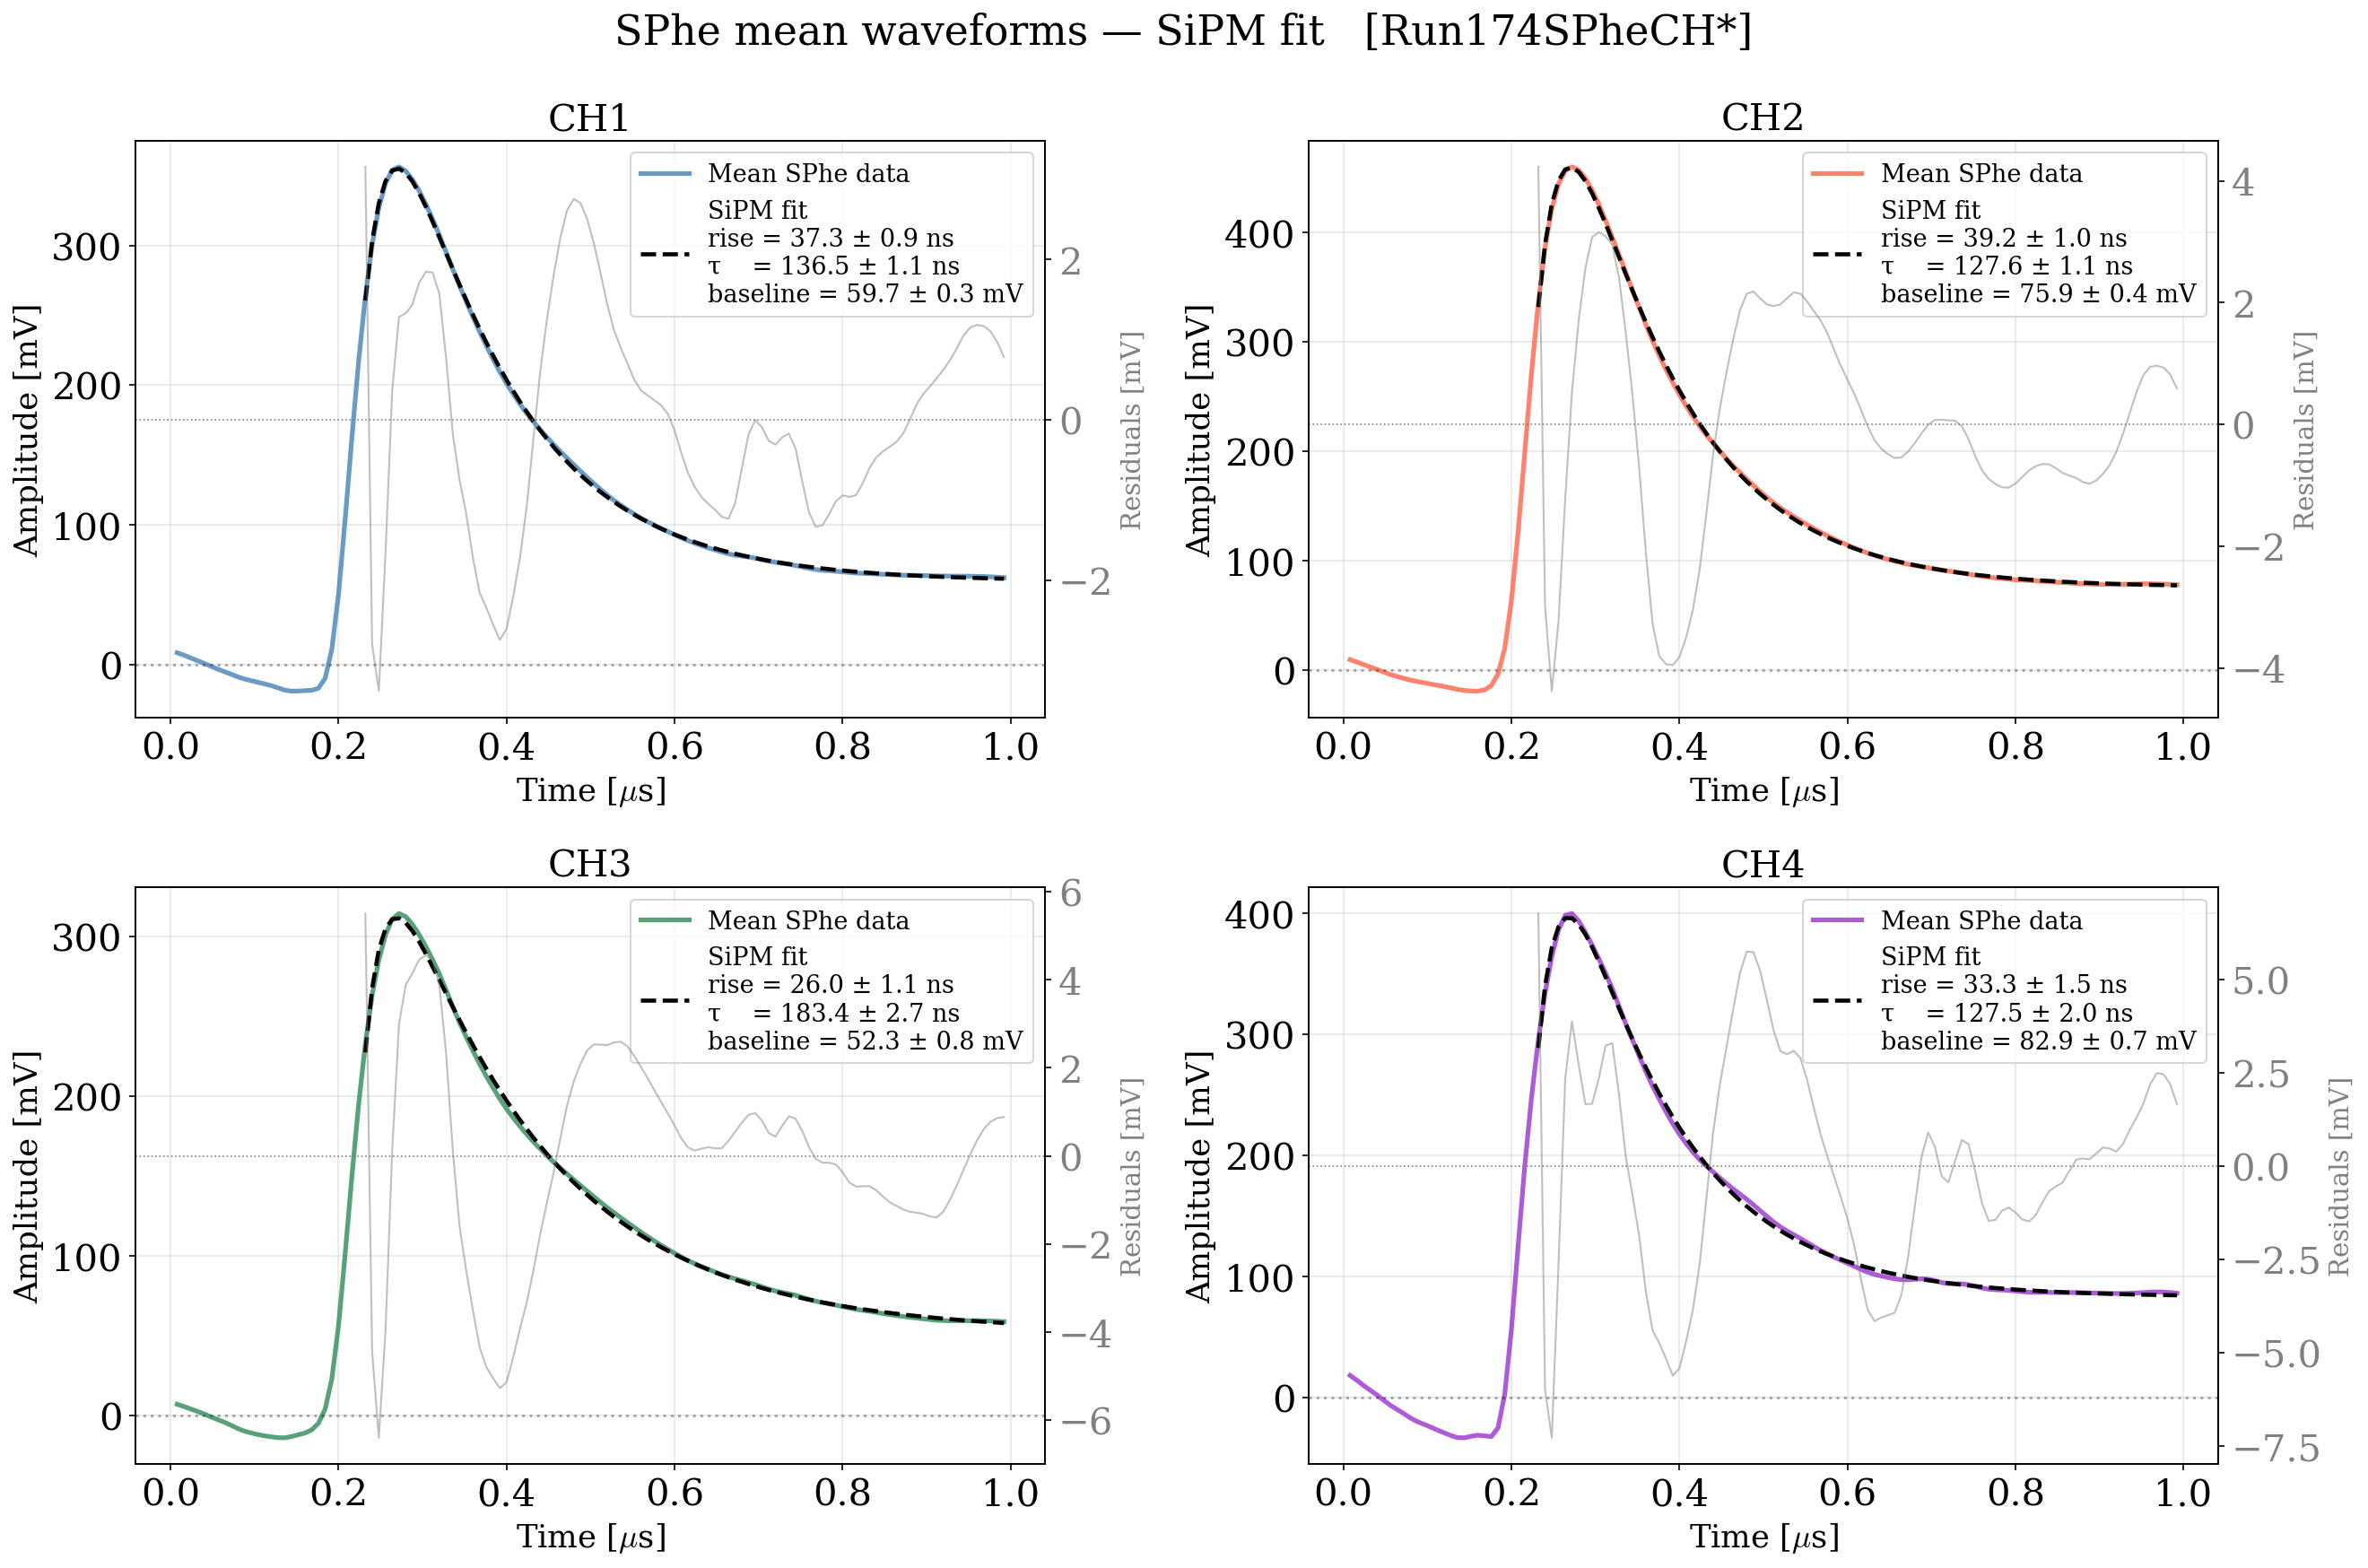

In [43]:
fig, _, sipm_params = fit_sphe_waveforms(run_base_sphe, base, ['CH1','CH2','CH3','CH4'],
                                      invert=False, p0=None, bounds=None,
                                      colors=None, font_size=20)

In [44]:
run_base_sphe     = 'Run187SPheCH'   # prefix; per-channel run dirs: Run172SPheCH1, Run172SPheCH2, ...

Loaded /home/marian/CIGAR_ANALYSIS/CIGAR/data/mean_waveforms/mean_waveforms_Run187SPheCH1.npz
Loaded /home/marian/CIGAR_ANALYSIS/CIGAR/data/mean_waveforms/mean_waveforms_Run187SPheCH2.npz
  ⚠ [CH1] rise         hit lower bound: value=1.5061e-08  lower=1.5000e-08


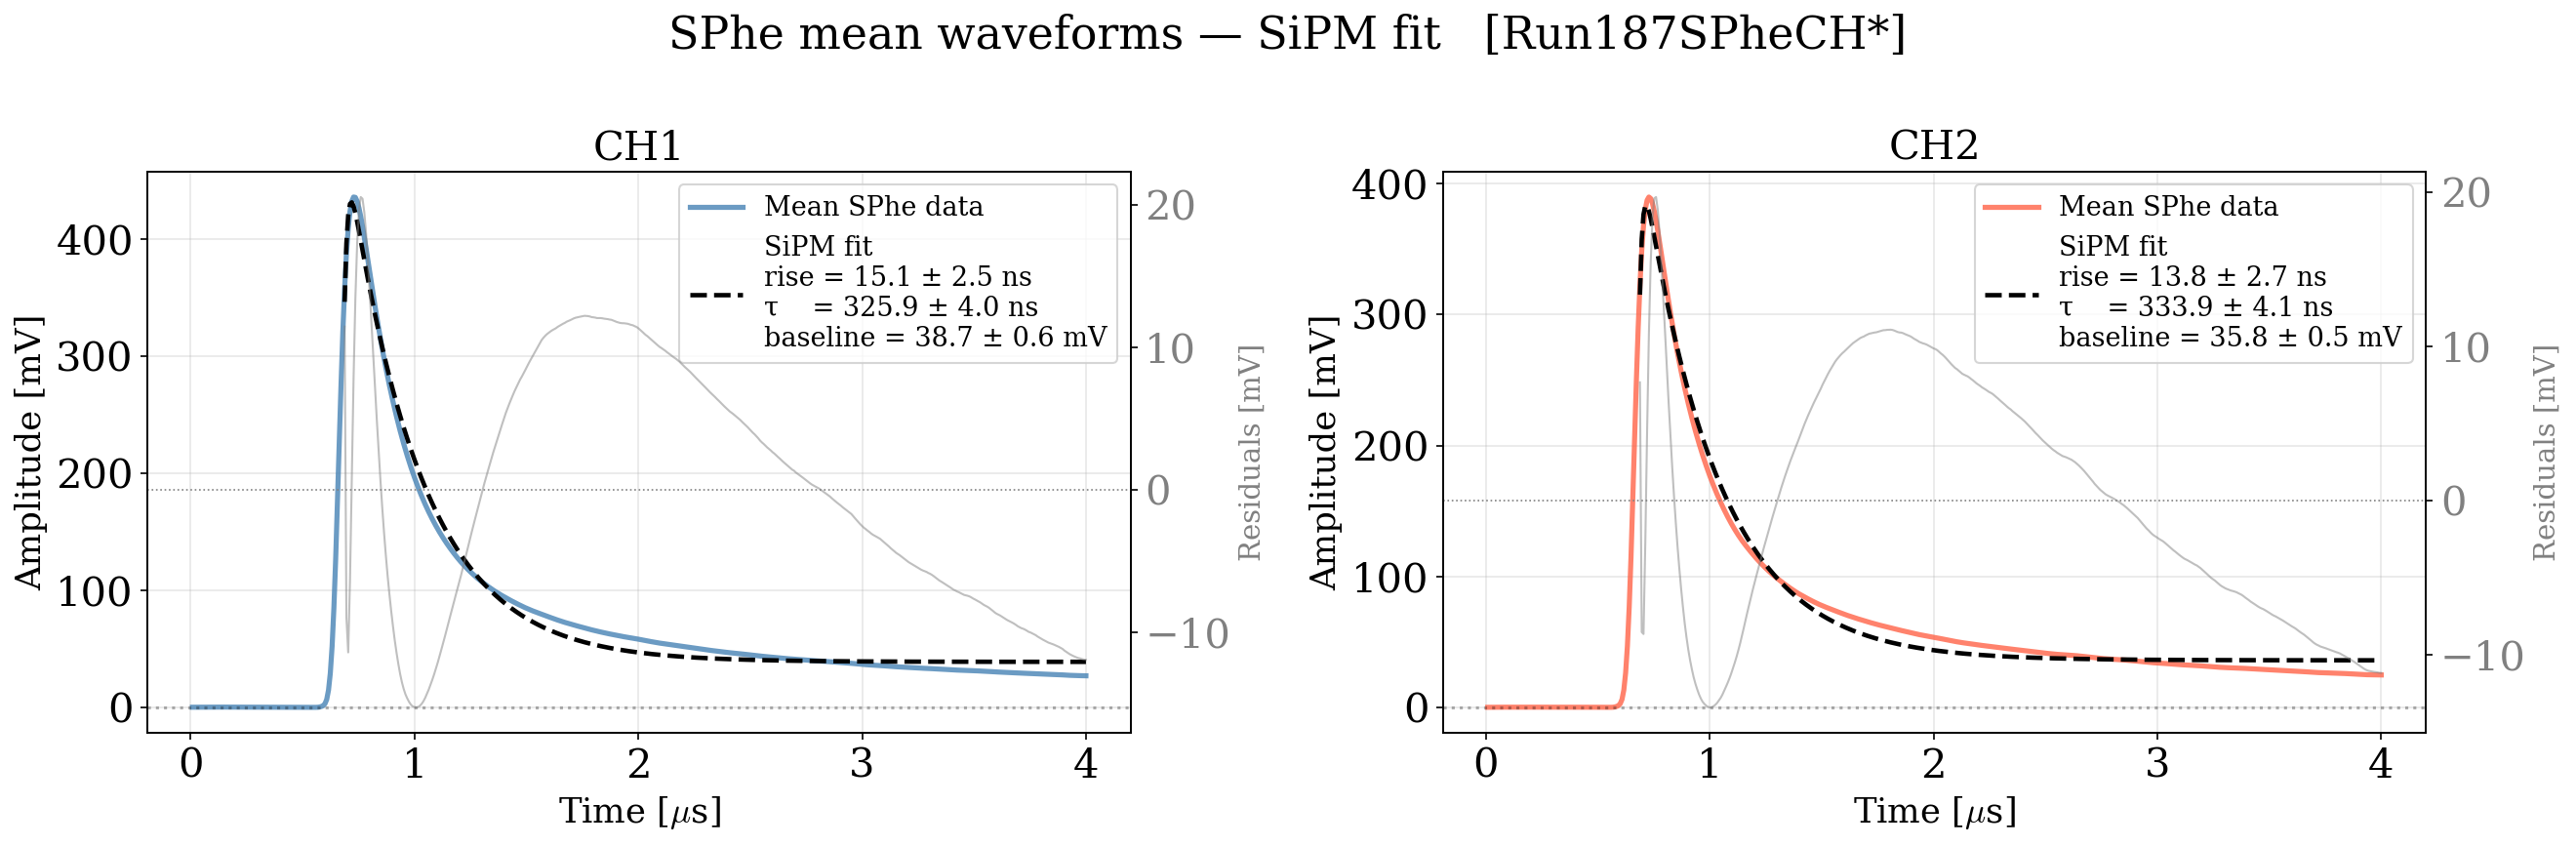

In [45]:
fig, axs, _ = fit_sphe_waveforms(run_base_sphe, base, ['CH1','CH2'],
                            invert=True, p0=None, bounds=None,
                            colors=None, font_size=20)


# for ax in axs.flatten():
#     ax.set_xlim(0.5, 1.5)
    
plt.show()

##  Signal time constants

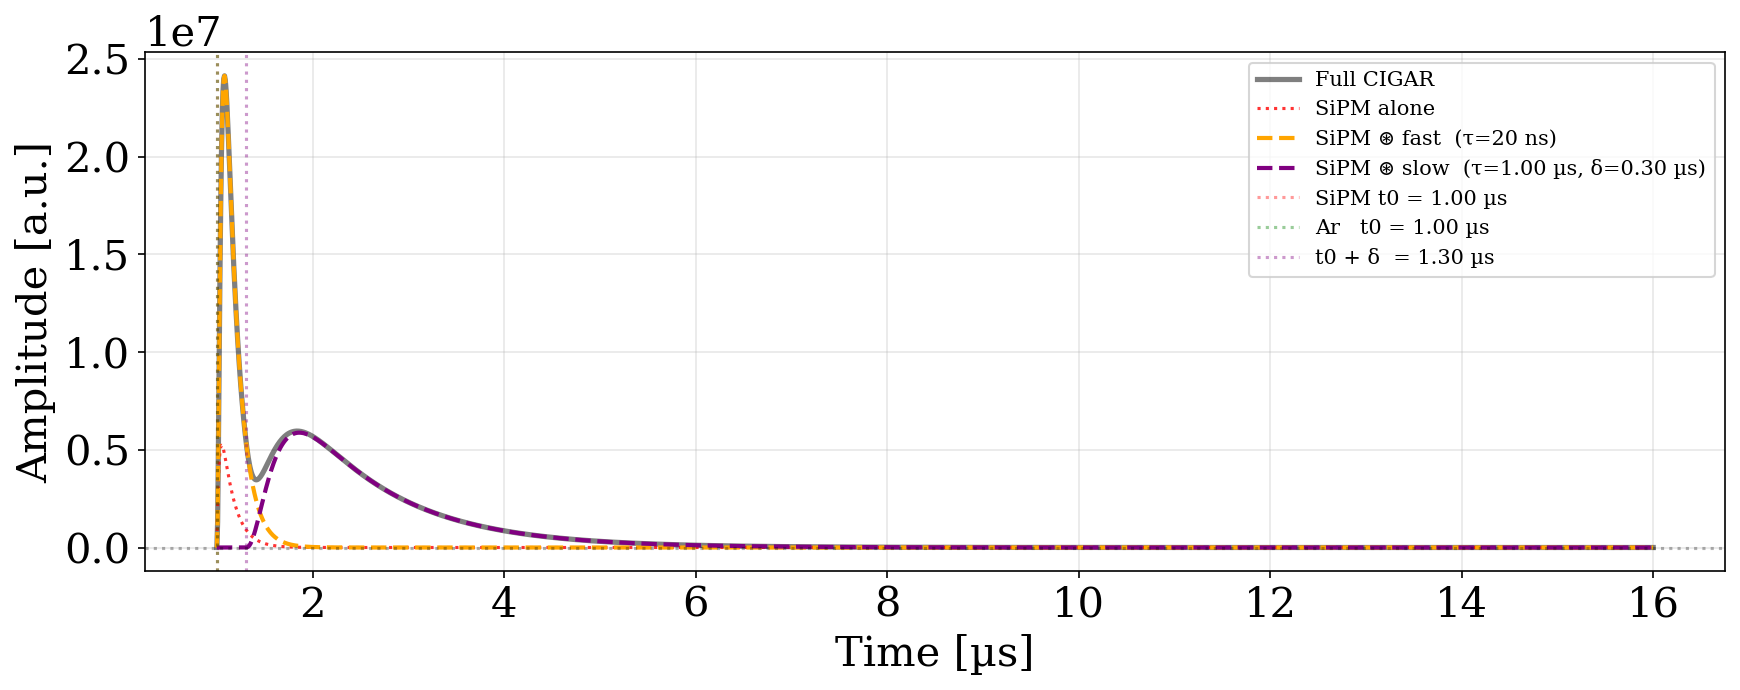

In [46]:
# =========================================================================== #
#  EXPLORER CELL — edit dicts and re-run                                       #
# =========================================================================== #
time = np.linspace(0, 16e-6, 2000)

sipm_p = dict(
    A    = 1.0,      # charge [PE]
    t0   = time[125],# onset fixed to pretrigger [s]
    rise = 30e-9,    # rise  constant [s]
    tau  = 130e-9,   # decay constant [s]
)

# t0_ar can differ from sipm_p['t0'] — try shifting it and see the effect
t0_ar = time[125]   # Ar scintillation onset [s]

fast_p = dict(
    A    = 5,      # amplitude [mV·s]
    rise = 2e-9,     # rise  [s]
    tau  = 20e-9,    # decay [s]
)

slow_p = dict(
    A          = 9,    # amplitude [mV·s]
    rise       = 200e-9,   # rise  [s]
    tau        = 1e-6,   # decay [s]
    delta_slow = 0.3e-6,   # WLS re-emission delay [s]
)


# ---- compute ------------------------------------------------------------- #
mask = time >= sipm_p['t0']
t    = time[mask]

h_fast = np.zeros_like(t)
u_fast = t - t0_ar
mf     = u_fast > 0
h_fast[mf] = _conv_two_rise_decay(u_fast[mf],
                                   sipm_p['rise'], sipm_p['tau'],
                                   fast_p['rise'], fast_p['tau'])
area = np.trapz(h_fast, x=t)
if area > 0: h_fast *= fast_p['A'] / area

h_slow = np.zeros_like(t)
u_slow = t - t0_ar - slow_p['delta_slow']
ms     = u_slow > 0
h_slow[ms] = _conv_two_rise_decay(u_slow[ms],
                                   sipm_p['rise'], sipm_p['tau'],
                                   slow_p['rise'], slow_p['tau'])
area = np.trapz(h_slow, x=t)
if area > 0: h_slow *= slow_p['A'] / area

sipm = ResponseSiPM(sipm_p['A'], t, sipm_p['t0'], sipm_p['rise'], sipm_p['tau'])
full = h_fast + h_slow

# ---- plot ---------------------------------------------------------------- #
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

ax.plot(t * 1e6, full,   color='black',  lw=2.5, alpha = 0.5, label='Full CIGAR')
ax.plot(t * 1e6, sipm,   color='red',    lw=1.5, ls=':',  alpha=.8, label='SiPM alone')
ax.plot(t * 1e6, h_fast, color='orange', lw=2,   ls='--',            label=f'SiPM ⊛ fast  (τ={fast_p["tau"]*1e9:.0f} ns)')
ax.plot(t * 1e6, h_slow, color='purple', lw=2,   ls='--',            label=f'SiPM ⊛ slow  (τ={slow_p["tau"]*1e6:.2f} µs, δ={slow_p["delta_slow"]*1e6:.2f} µs)')

ax.axvline(sipm_p['t0']  * 1e6, color='red',    ls=':', alpha=0.4, label=f'SiPM t0 = {sipm_p["t0"]*1e6:.2f} µs')
ax.axvline(t0_ar         * 1e6, color='green',  ls=':', alpha=0.4, label=f'Ar   t0 = {t0_ar*1e6:.2f} µs')
ax.axvline((t0_ar + slow_p['delta_slow']) * 1e6,
                               color='purple', ls=':', alpha=0.4, label=f't0 + δ  = {(t0_ar+slow_p["delta_slow"])*1e6:.2f} µs')
ax.axhline(0, color='k', ls=':', alpha=0.3)
ax.set_xlabel('Time [µs]')
ax.set_ylabel('Amplitude [a.u.]')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
run    = {
          #  8.5:f'Run{171}' 
         #   7.5:f'Run{173}'
        #    6.5:f'Run{175}'
        #    5.5:f'Run{177}'
         #   4.5:f'Run{179}'
        #    3.5:f'Run{181}'
        #    2.5:f'Run{183}'
           1.5:f'Run{185}'
           }

  ⚠ [CH1] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0
  ⚠ [CH2] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0
  ⚠ [CH3] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0
  ⚠ [CH4] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0


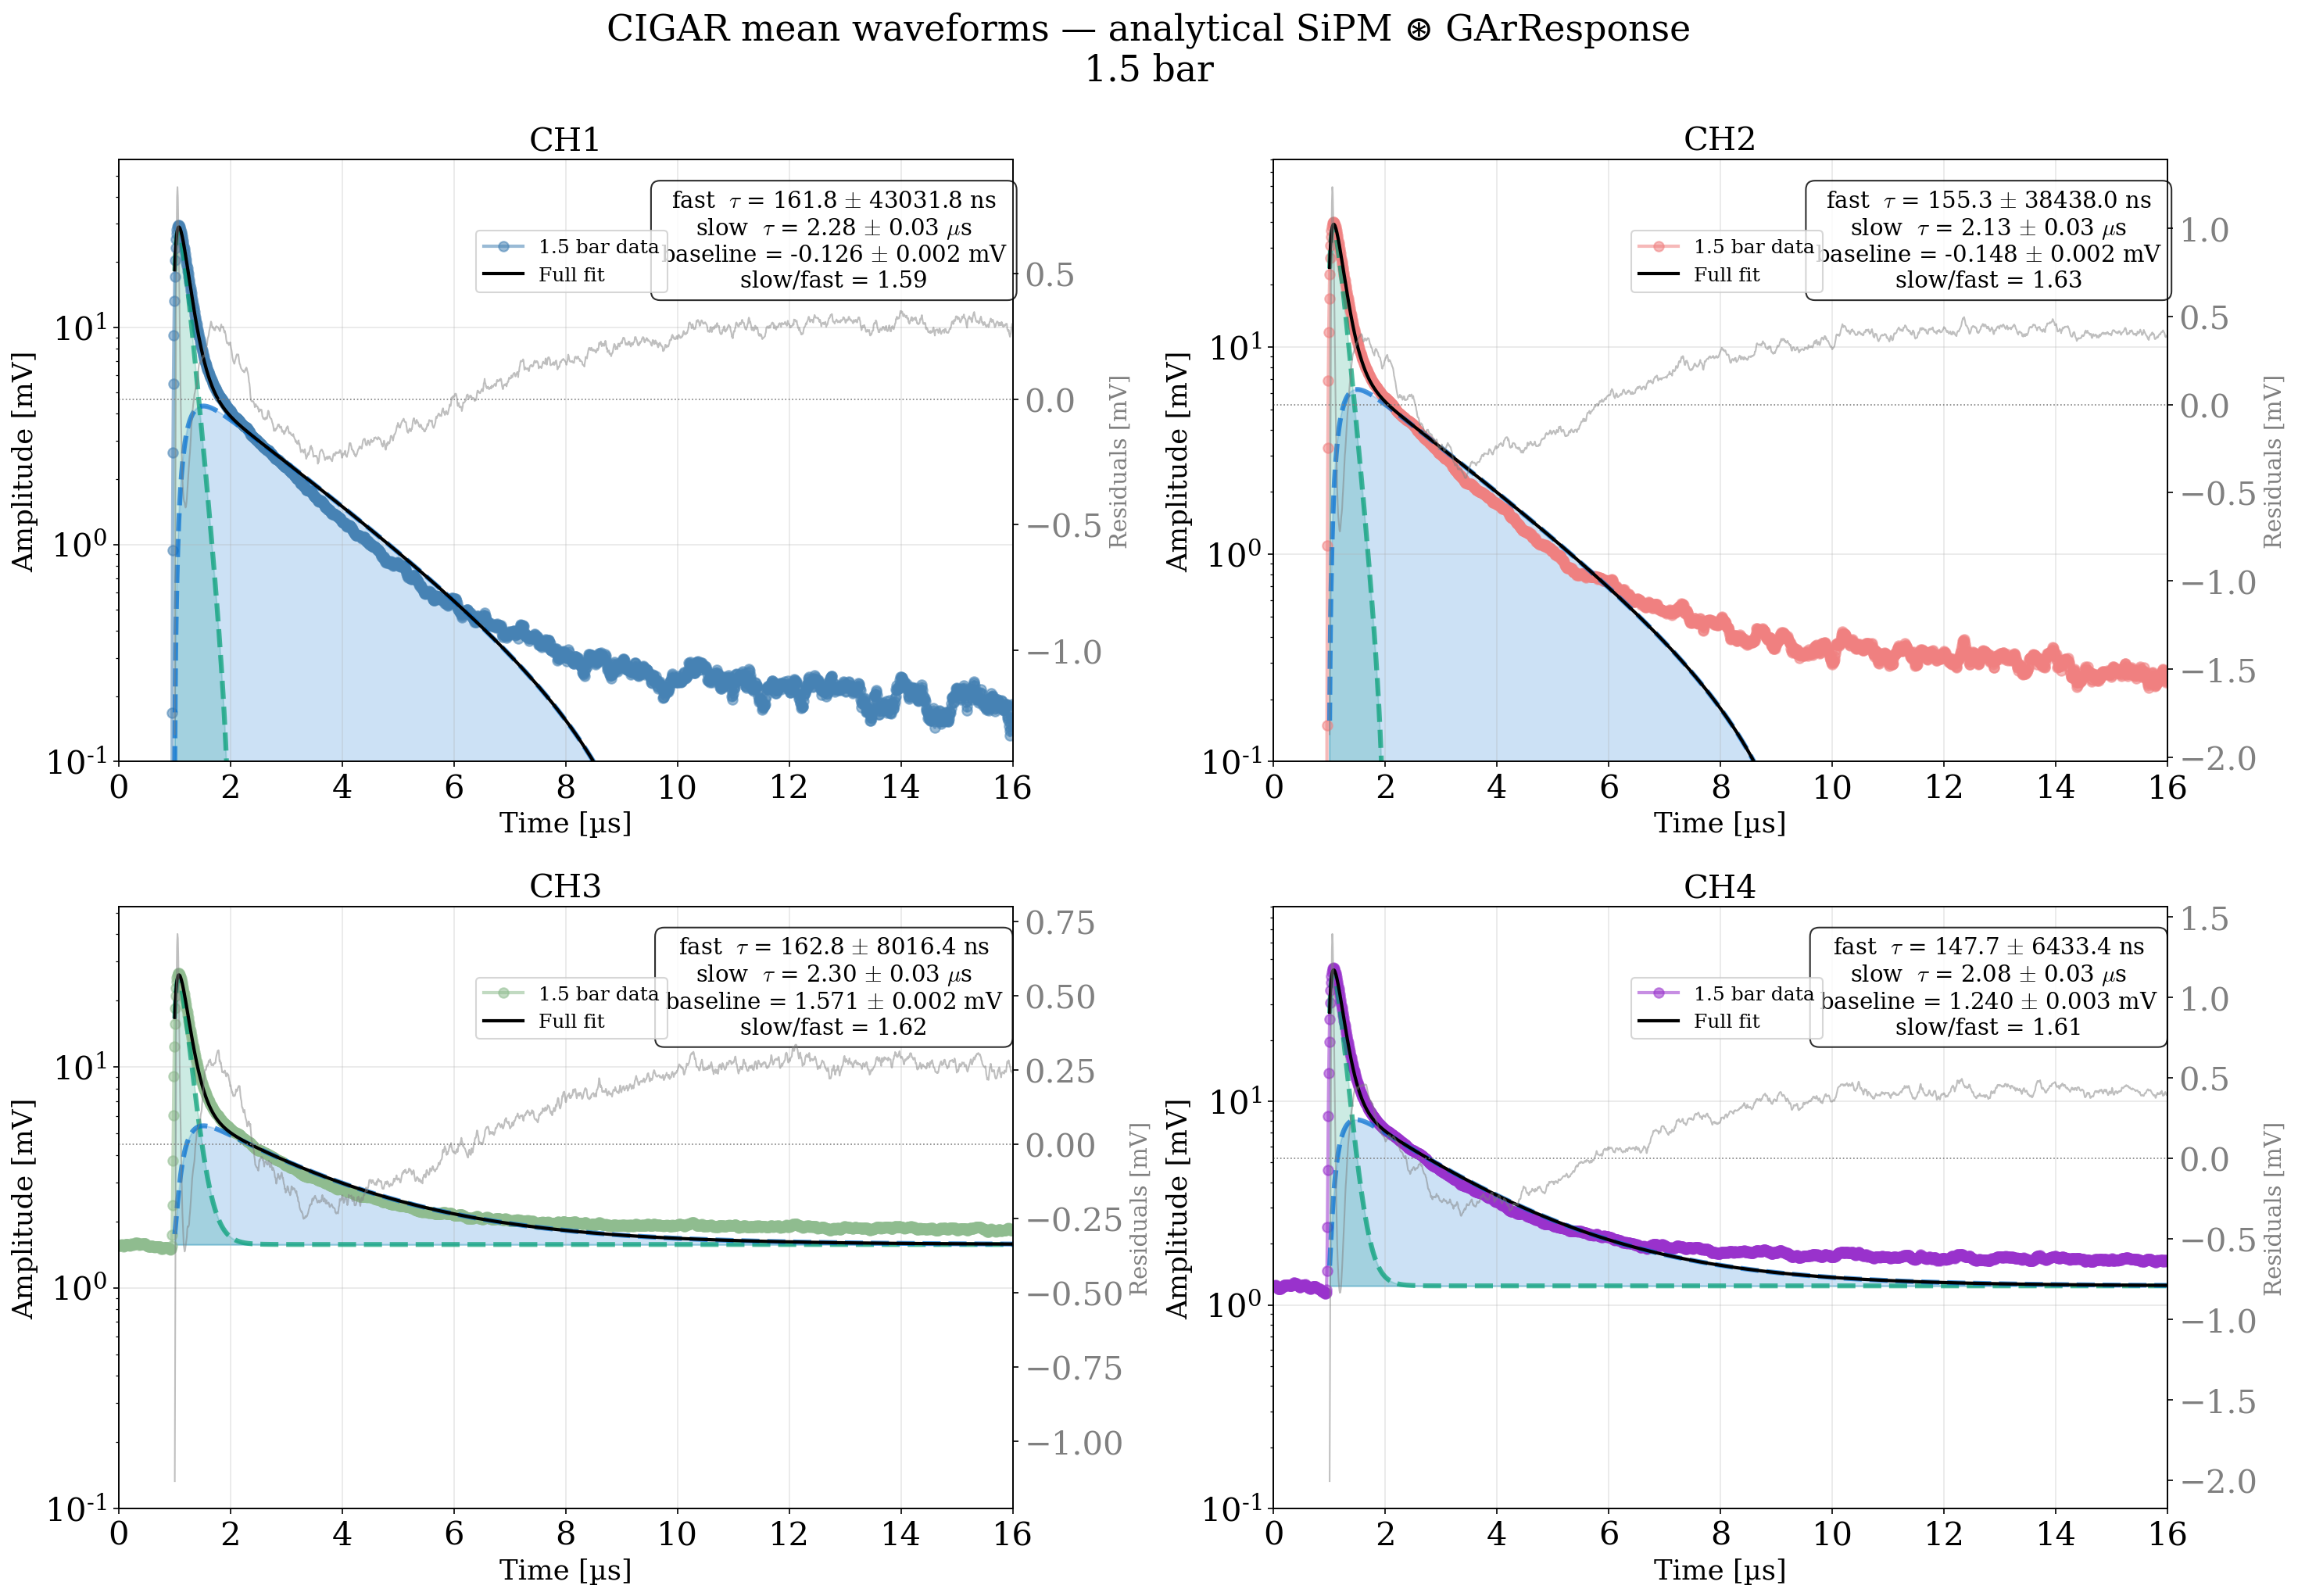

In [48]:
fig_cig, axs, cigar_params = fit_cigar_waveforms(run, base
                                                 ,pretrigger_sample=125
                                                 ,channels_to_show=None, invert=True
                                                 ,p0_cigar=None, bounds_cigar=None
                                                 ,colors=None, font_size=20
                                                 ,logscale = True
                                                 )

for ax in axs.flatten():
    ax.set_ylim(1, 30)

plt.show()

In [49]:
runs    = {
        #    8.5:f'Run{171}' 
        #    ,7.5:f'Run{173}'
        #    ,6.5:f'Run{175}'
        #    ,5.5:f'Run{177}'
        #    ,4.5:f'Run{179}'
        #    ,3.5:f'Run{181}'
           2.5:f'Run{183}'
           ,1.5:f'Run{185}'
           }

  ⚠ [CH1] rise_fast    hit lower bound: value=1.6479e-11  lower=1.0000e-11
5: 0
  ⚠ [CH2] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0
  ⚠ [CH3] rise_fast    hit lower bound: value=1.1968e-10  lower=1.0000e-11
5: 0
  ⚠ [CH4] rise_fast    hit lower bound: value=1.0331e-10  lower=1.0000e-11
5: 0


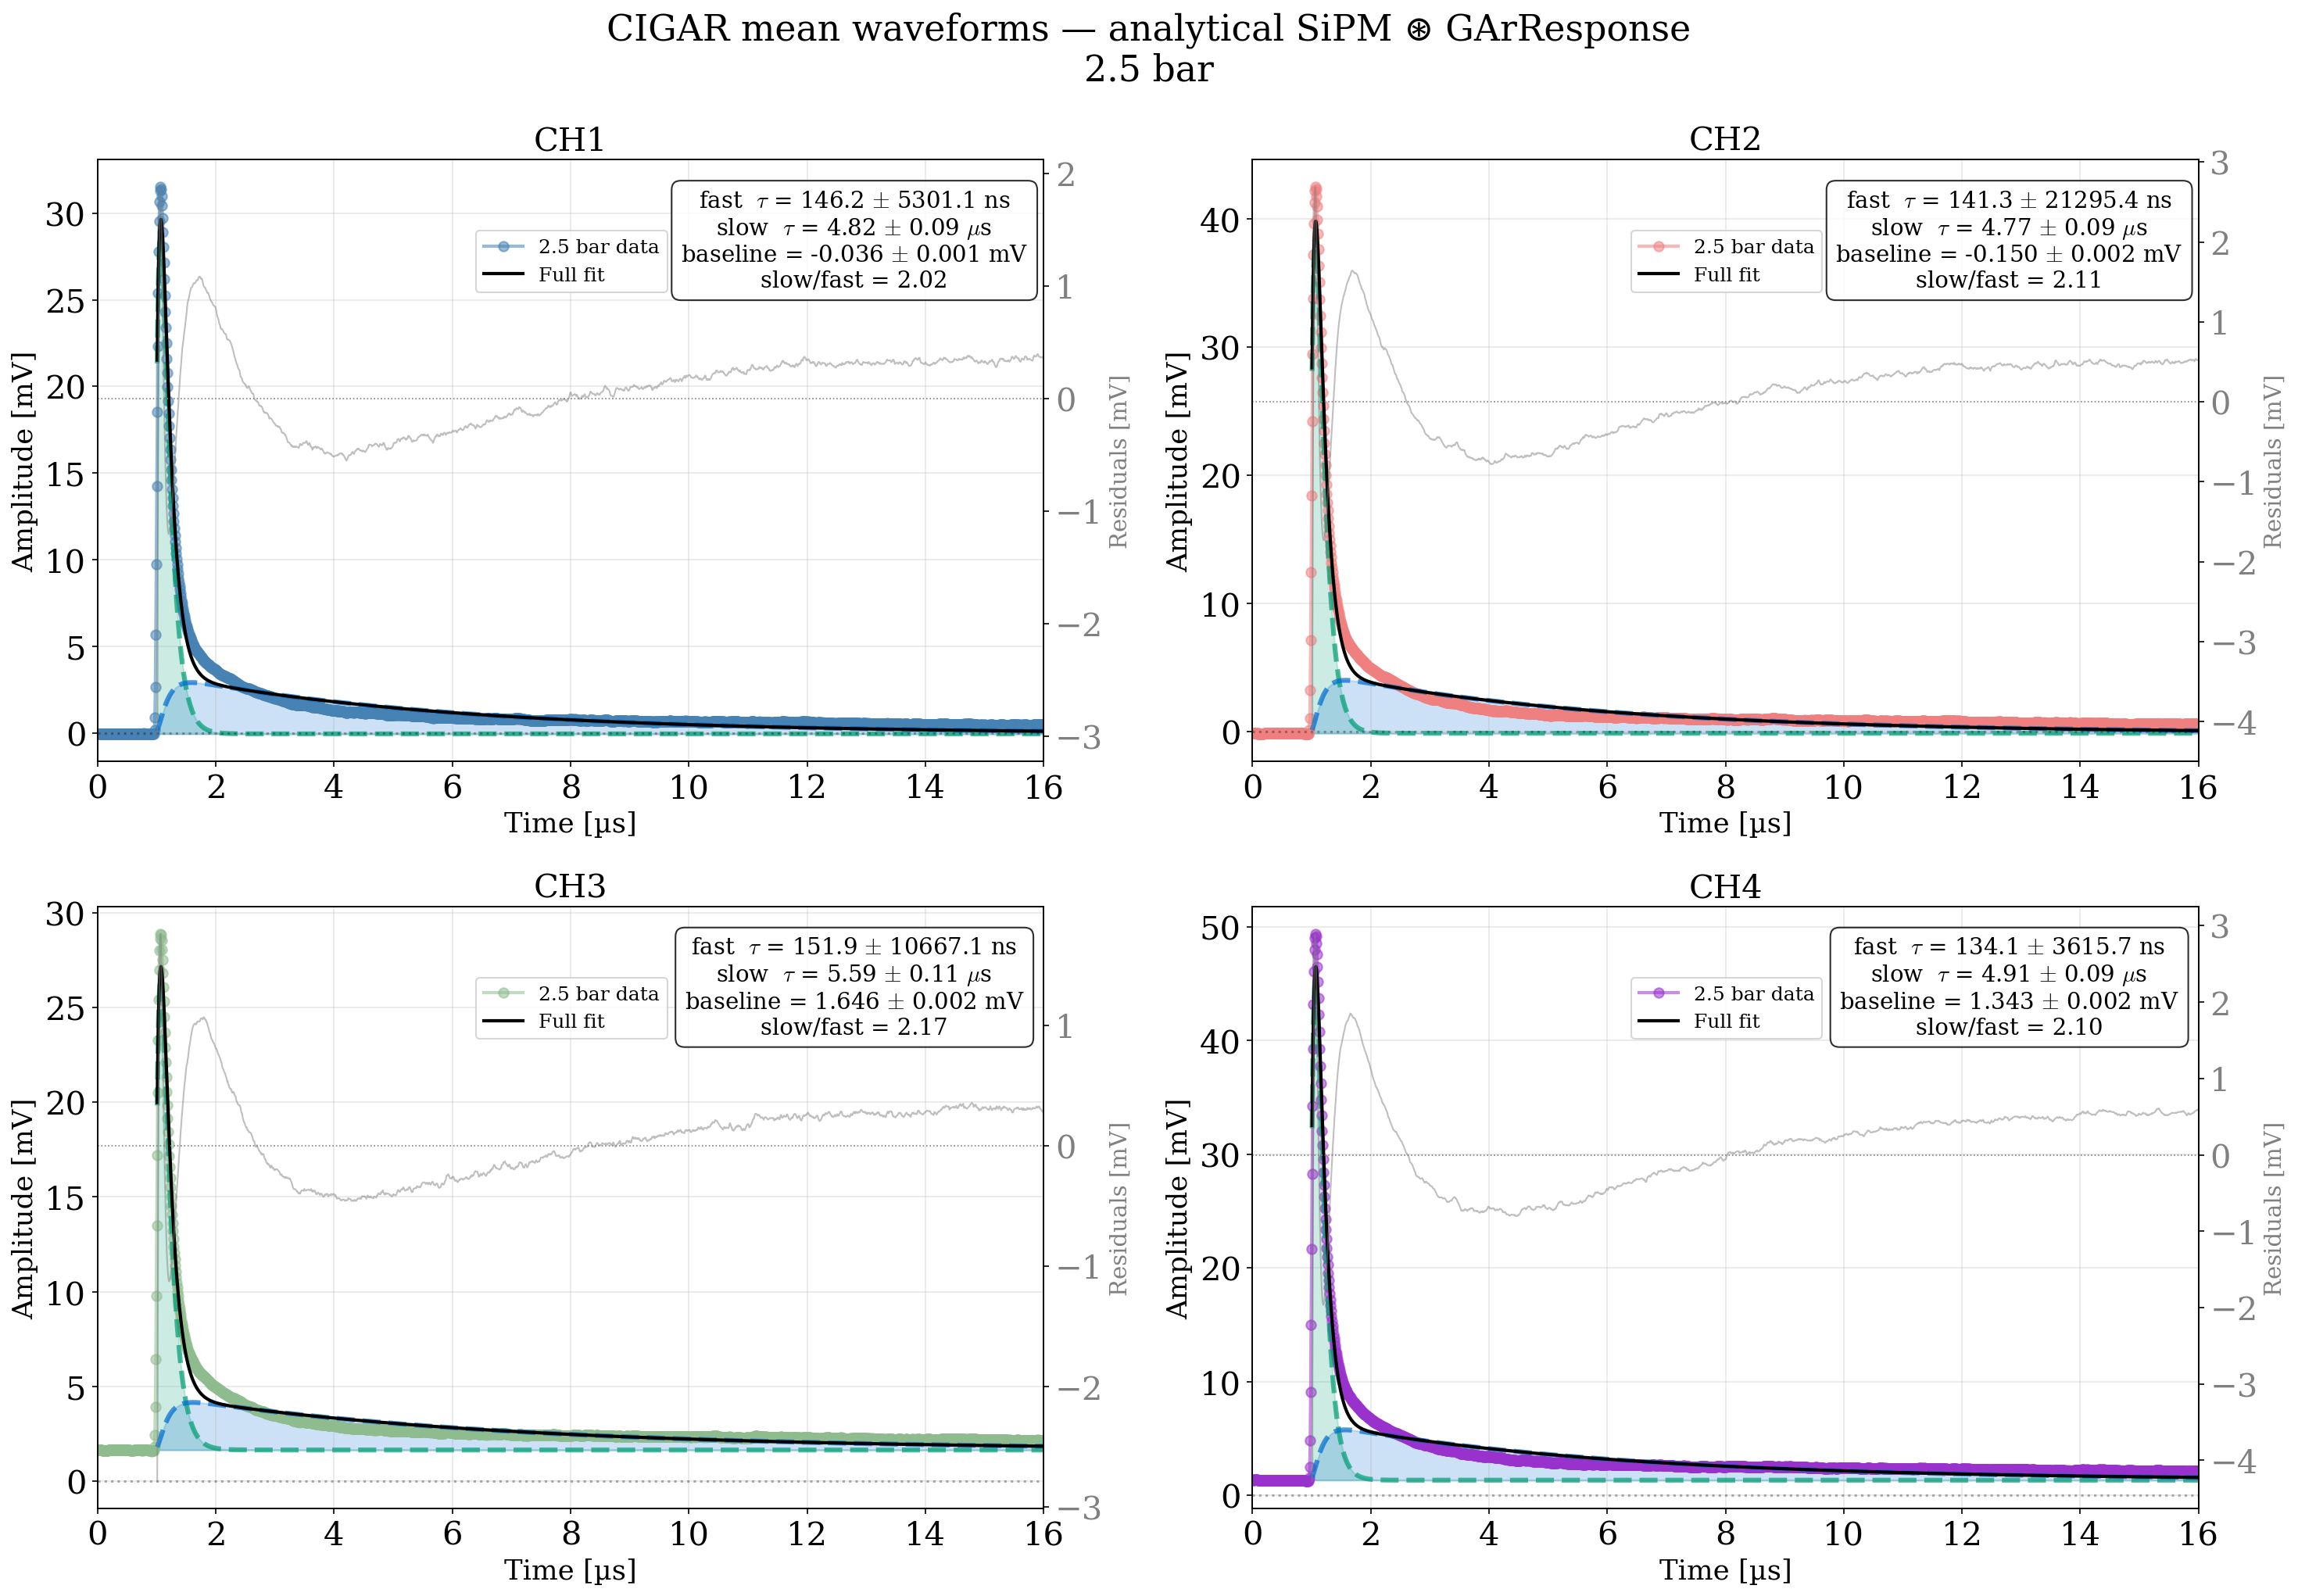

  ⚠ [CH1] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0
  ⚠ [CH2] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0
  ⚠ [CH3] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0
  ⚠ [CH4] rise_fast    hit lower bound: value=1.6478e-11  lower=1.0000e-11
5: 0


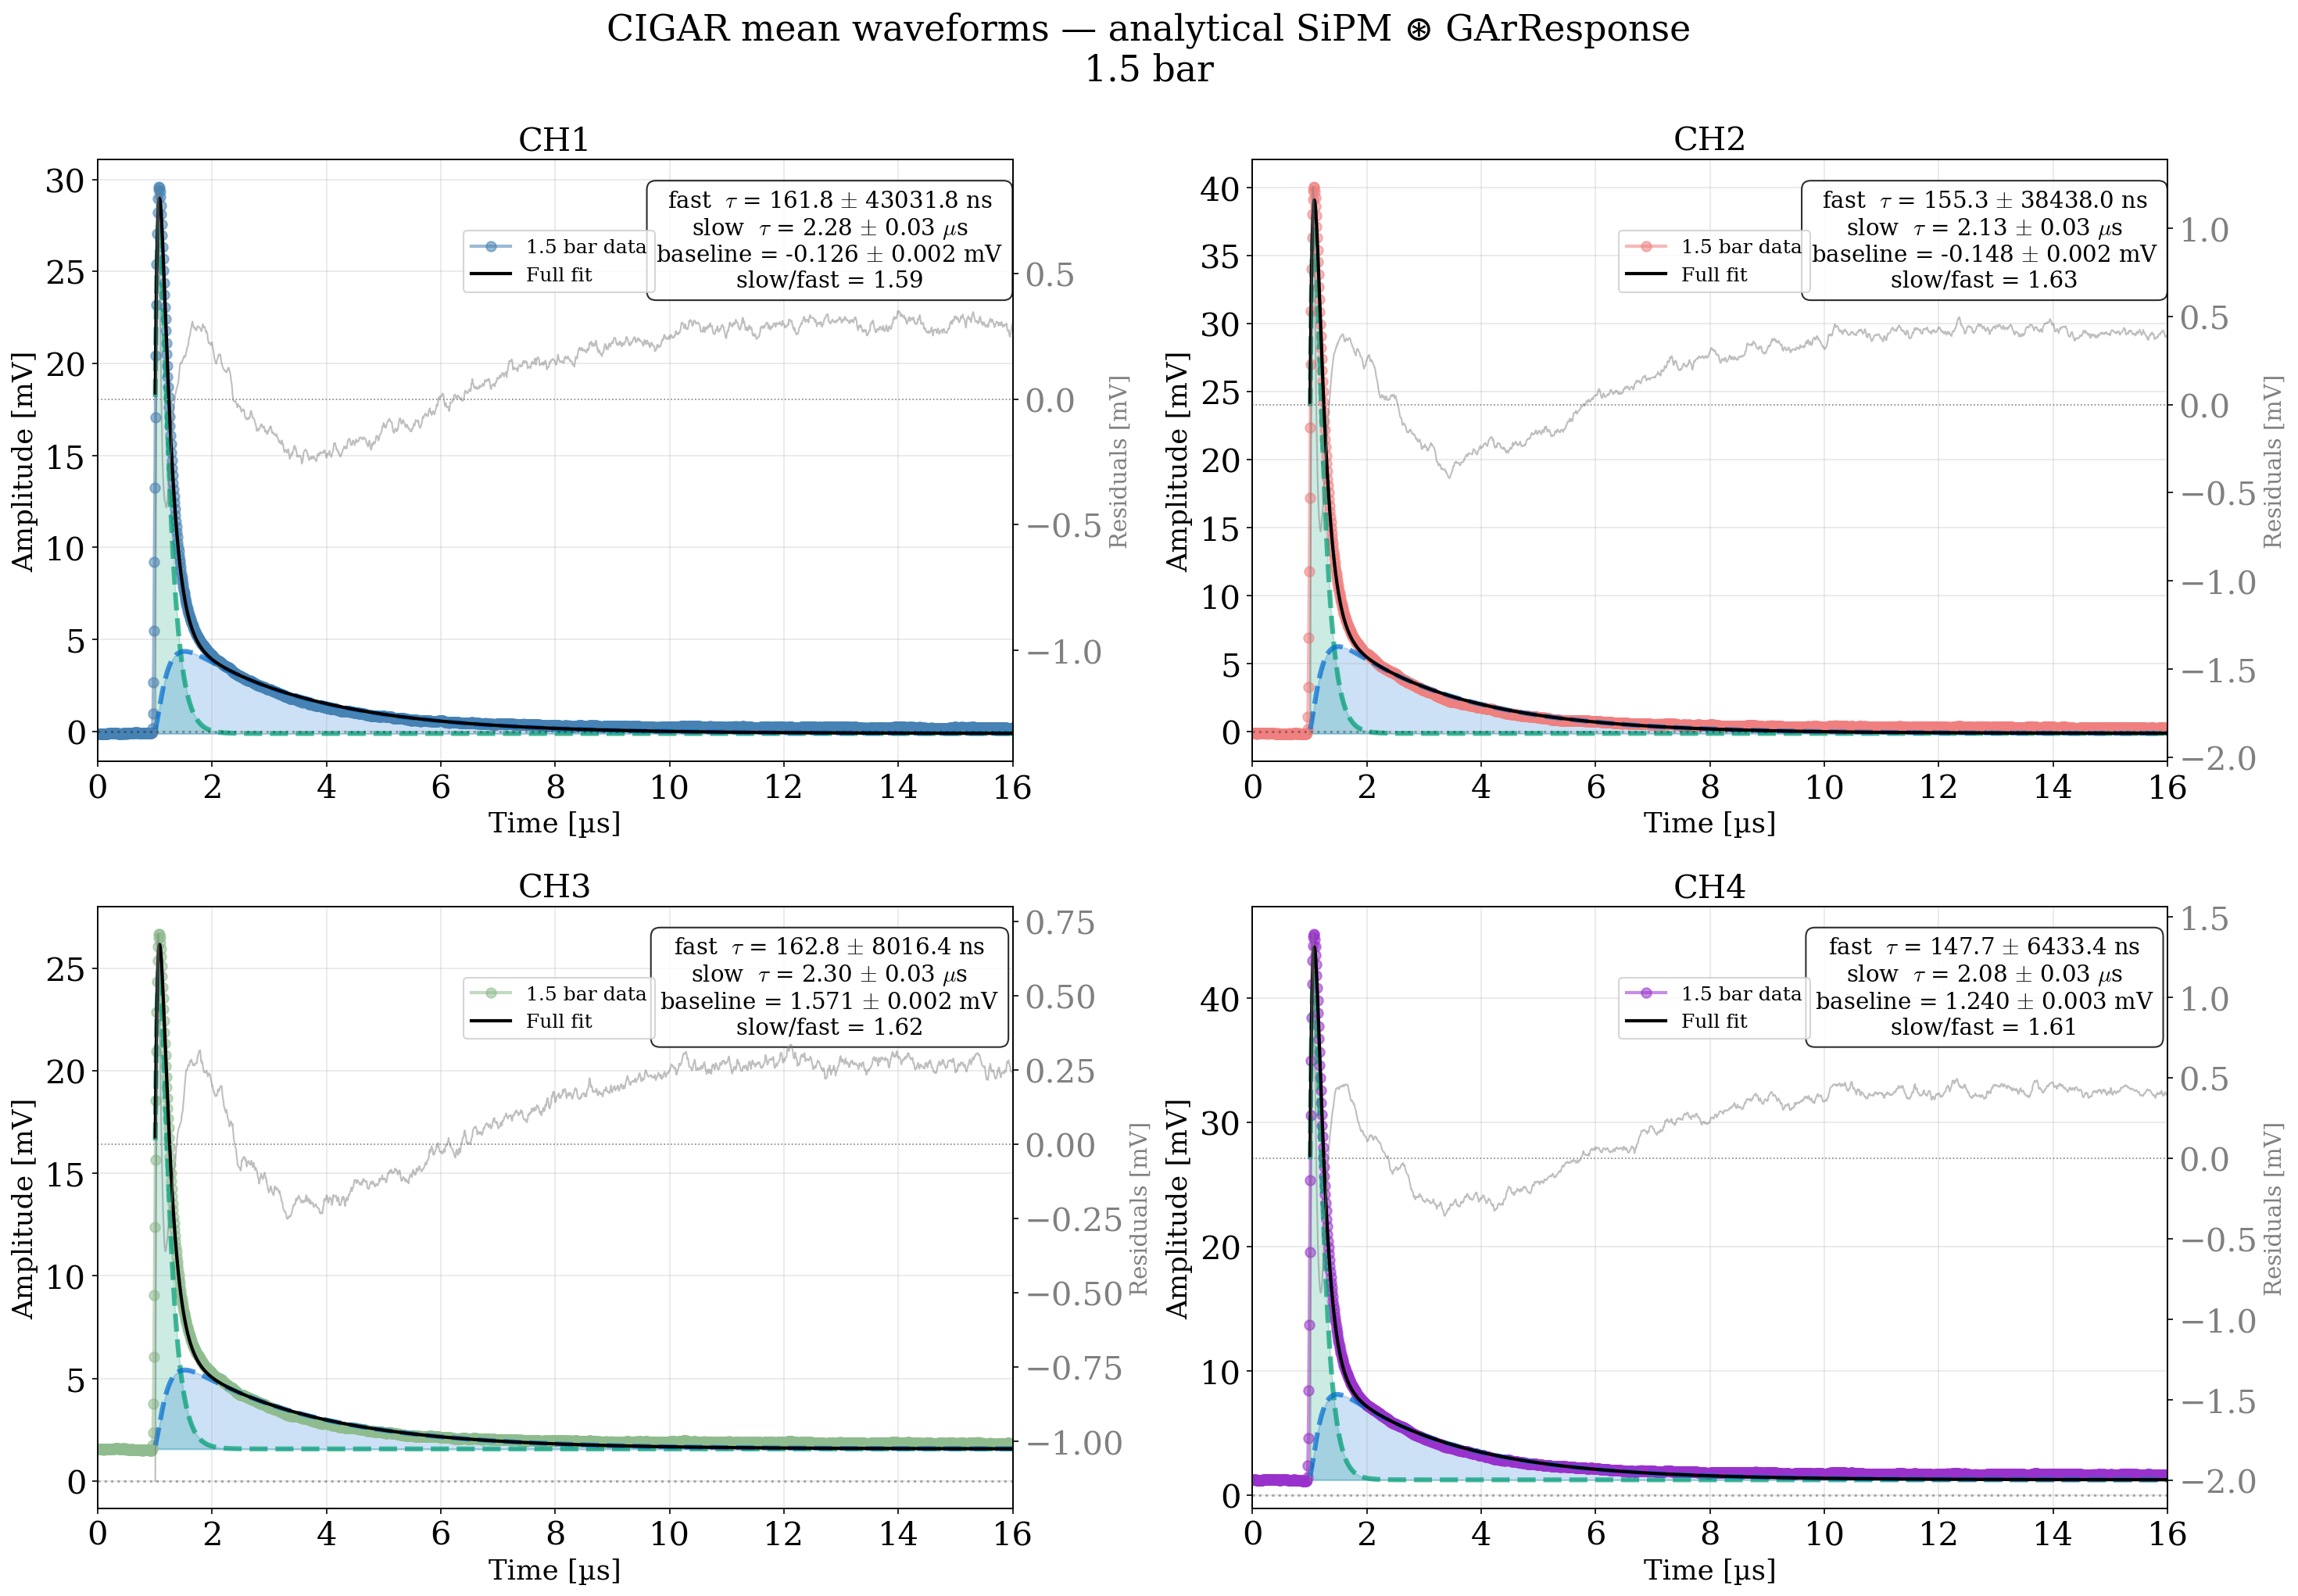

DONE!


In [50]:
# fast_decay, slow_decay per channel per pressure
fd, sd = {}, {}   # {ch: {pressure: (value, error)}}

for bars, run_name in runs.items():
    run = {bars: run_name}
    fig, axs_cig, cp = fit_cigar_waveforms(run, base,
                                           pretrigger_sample = 125,
                                           channels_to_show  = None,
                                           invert            = True,
                                           p0_cigar          = None,
                                           bounds_cigar      = None,
                                           colors            = None,
                                           font_size         = 20,
                                           logscale          = False,
                                           )
    plt.show()

    for ch in cp:
        if ch not in fd:
            fd[ch] = {}
            sd[ch] = {}
        fd[ch][bars] = (cp[ch]['tau_fast'], np.sqrt(cp[ch]['pcov'][3, 3]))
        sd[ch][bars] = (cp[ch]['tau_slow'], np.sqrt(cp[ch]['pcov'][6, 6]))

print('DONE!')

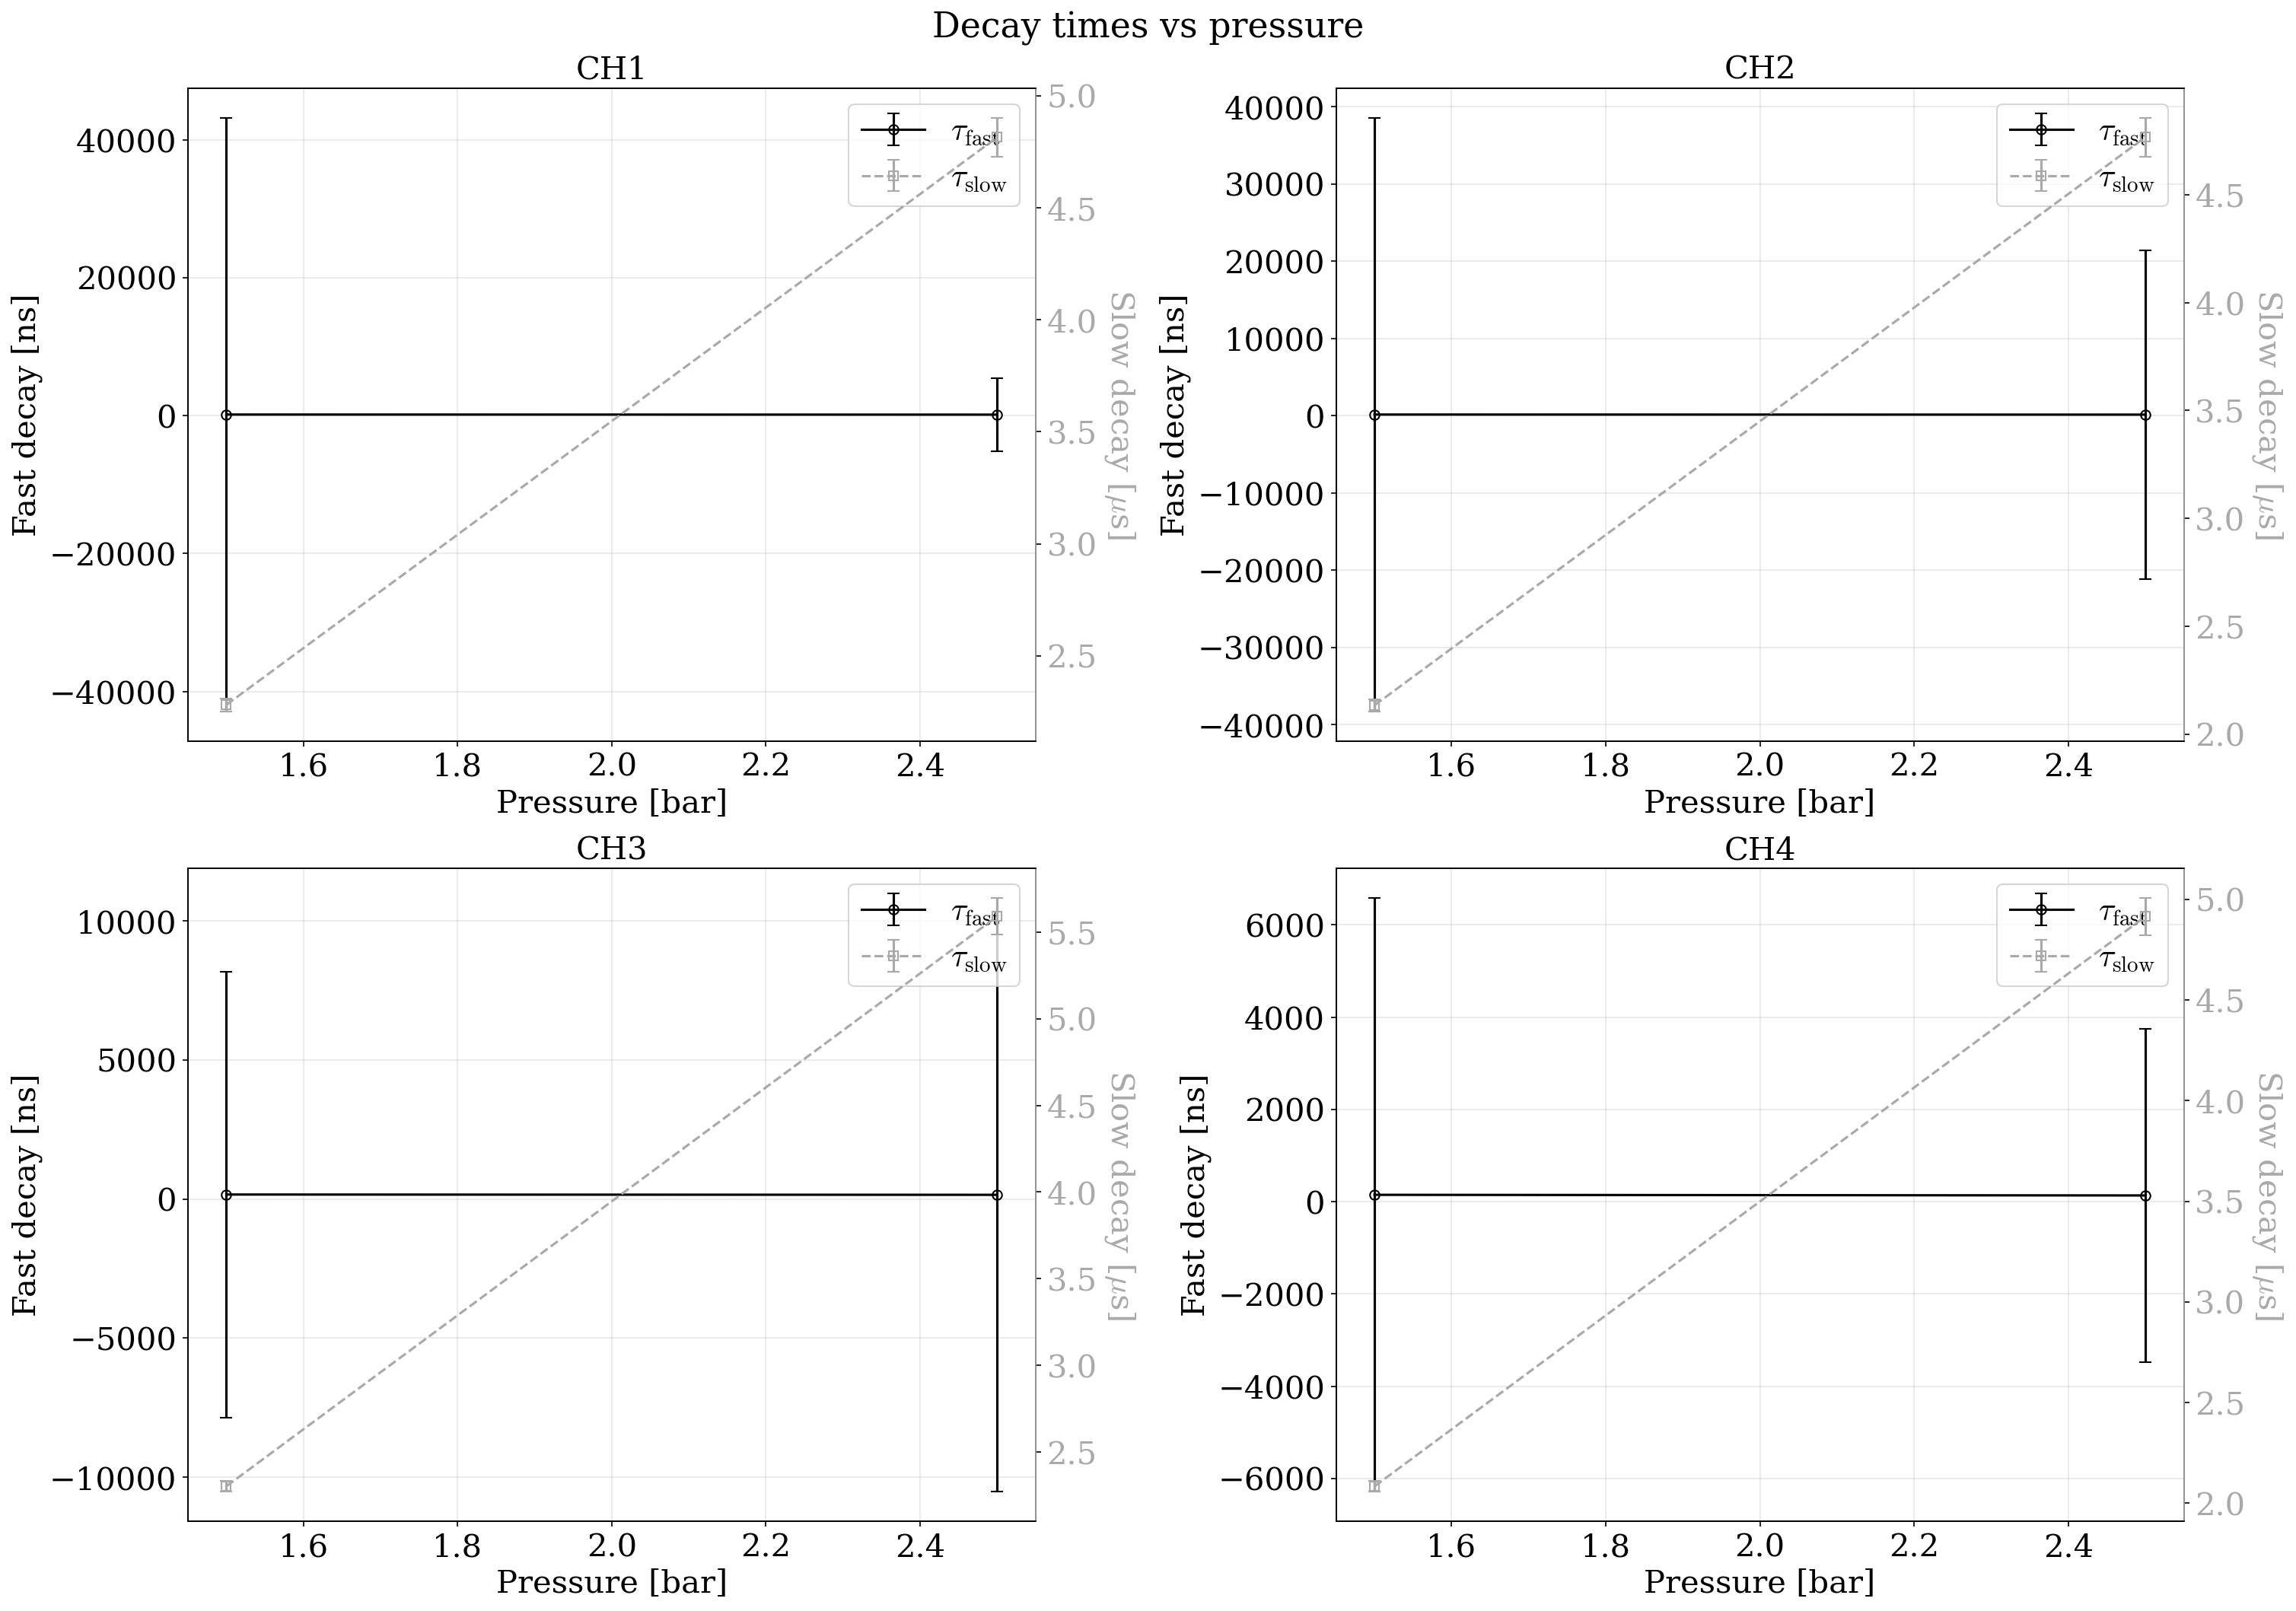

In [51]:
fig, axs = plt.subplots(2, 2, figsize=(20, 14), dpi=150, constrained_layout=True)
fig.suptitle('Decay times vs pressure', fontsize=font_size + 2)

for ii, ch in enumerate(sorted(fd.keys())):
    ax  = axs.flat[ii]
    ax2 = ax.twinx()

    bars_list = sorted(fd[ch].keys())
    tau_fast  = np.array([fd[ch][b][0] for b in bars_list]) * 1e9   # ns
    err_fast  = np.array([fd[ch][b][1] for b in bars_list]) * 1e9
    tau_slow  = np.array([sd[ch][b][0] for b in bars_list]) * 1e6   # µs
    err_slow  = np.array([sd[ch][b][1] for b in bars_list]) * 1e6

    ax.errorbar(bars_list, tau_fast, yerr=err_fast,
                fmt='o-', color='black',
                markerfacecolor='none', markeredgecolor='black',
                label=r'$\tau_\mathrm{fast}$', capsize=4)

    ax2.errorbar(bars_list, tau_slow, yerr=err_slow,
                 fmt='s--', color='darkgray',
                 markerfacecolor='none', markeredgecolor='darkgray',
                 label=r'$\tau_\mathrm{slow}$', capsize=4)

    ax.set_title(ch, fontsize=font_size)
    ax.set_xlabel('Pressure [bar]',   fontsize=font_size)
    ax.set_ylabel('Fast decay [ns]',  fontsize=font_size)
    ax.tick_params(axis='y', labelcolor='black')

    ax2.set_ylabel(r'Slow decay [$\mu$s]', fontsize=font_size, rotation=270, labelpad=25)
    ax2.tick_params(axis='y', labelcolor='darkgray')
    ax2.yaxis.label.set_color('darkgray')
    ax2.spines['right'].set_color('darkgray')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=font_size, loc='upper right')

    ax.grid(True, alpha=0.3)

plt.show()